<h2>Are American Robins Really a Sign of Spring? An Analysis of Complete eBird Checklists in North Carolina from 2021-2025</h2>

<b>Question:</b> Are American Robins reported in a higher proportion of complete eBird checklists during spring than other times of the year in North Carolina?

In the United States, American Robins are known to be the first signs of spring, despite being considered a year-round bird. This project uses data from eBird to see if there is a meaningful increase in their reporting during spring.

<a href="https://ebird.org/home">eBird</a> is a platform that anyone can contribute to (citizen science).

In [185]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Data Description: The datasets are downloaded from <a href="https://science.ebird.org/en/use-ebird-data/download-ebird-data-products">here</a>. I filtered my data to be checklists with American Robins in North Carolina from 2021-2025.

The download comes with two datasets: Sampling Event Data and EBD (eBird Basic Dataset). 

In [186]:
# load in data

# Sampling Event Data = contains EVERY checklist in NC from 2021-2025 regardless if American Robin was observed
df_all_checklists = pd.read_csv("data/ebd_US-NC_amerob_202101_202512_smp_relJun-2026_sampling.txt", 
                                sep="\t", 
                                usecols=["SAMPLING EVENT IDENTIFIER", "OBSERVATION DATE", "ALL SPECIES REPORTED"])

# EBD = eBird Basic Dataset, contains ONLY checklists in NC from 2021-2025 where American Robin was observed
df_ar_only_checklists = pd.read_csv("data/ebd_US-NC_amerob_202101_202512_smp_relJun-2026.txt", 
                                    sep="\t", 
                                    usecols=["SAMPLING EVENT IDENTIFIER"])

# keep only relevant columns
# Sampling Event Identifier: unique alphanumeric id for each "sampling event" ie checklist
# Observation Date: date the checklist was created
# All Species Reported: whether the checklist is complete or not. we want to filter to complete checklists only to reduce bias
# We only need the sampling event id column for EBD, because we will join these two. these are just all the rows that contain a robin, the other info is the same

In [187]:
print(df_all_checklists.head())
print(df_ar_only_checklists.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED
0       2021-01-01                 S97910779                     0
1       2021-01-01                 S80813471                     0
2       2021-01-01                 S79515367                     0
3       2021-01-01                 S82780949                     0
4       2021-01-01                 S78407716                     1
  SAMPLING EVENT IDENTIFIER
0                 S78960242
1                 S79477418
2                 S79668245
3                 S79849364
4                 S79473462


In [188]:
# Check and clean data
print((df_all_checklists.dtypes))

# check if there are any missing values
print(df_all_checklists["OBSERVATION DATE"].isna().sum())
print(df_all_checklists["SAMPLING EVENT IDENTIFIER"].isna().sum())
print(df_all_checklists["ALL SPECIES REPORTED"].isna().sum())

OBSERVATION DATE             object
SAMPLING EVENT IDENTIFIER    object
ALL SPECIES REPORTED          int64
dtype: object
0
0
0


In [189]:
# Convert to datetime
df_all_checklists["OBSERVATION DATE"] = pd.to_datetime(df_all_checklists["OBSERVATION DATE"])
print(df_all_checklists["OBSERVATION DATE"])

0         2021-01-01
1         2021-01-01
2         2021-01-01
3         2021-01-01
4         2021-01-01
             ...    
1416857   2025-12-31
1416858   2025-12-31
1416859   2025-12-31
1416860   2025-12-31
1416861   2025-12-31
Name: OBSERVATION DATE, Length: 1416862, dtype: datetime64[ns]


In [190]:
df_ar_only_checklists.head()

,SAMPLING EVENT IDENTIFIER
0,S78960242
1,S79477418
2,S79668245
3,S79849364
4,S79473462


In [191]:
# Check how "All Species Reported" is encoded
# 1 = True, completed checklist
# 0 = False, not completed checklist
# explain what a completed checklist means and its importance
df_all_checklists["ALL SPECIES REPORTED"].value_counts()

1    1128849
0     288013
Name: ALL SPECIES REPORTED, dtype: int64

In [192]:
# Filter complete checklists ONLY ie All Species Reported = 1
df_all_checklists = df_all_checklists.query("`ALL SPECIES REPORTED` == 1")

# Check that only complete checklists remain
print(len(df_all_checklists))
print(df_all_checklists["ALL SPECIES REPORTED"].sum())
# they are equal


1128849
1128849


In [193]:
# create a new variable: robin_reported for ebd
print(len(df_ar_only_checklists))

# Since every checklist contains a Robin observation, we can assign each row to have a new variable called robin_reported
# 1 = checklist contains robin
# 0 = checklist does not contain robin

df_ar_only_checklists["robin_reported"] = 1
print(df_ar_only_checklists.head())

396766
  SAMPLING EVENT IDENTIFIER  robin_reported
0                 S78960242               1
1                 S79477418               1
2                 S79668245               1
3                 S79849364               1
4                 S79473462               1


In [194]:
# merge
df_merged = pd.merge(left = df_all_checklists, right = df_ar_only_checklists, how = "left", on = "SAMPLING EVENT IDENTIFIER")
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             1.0  


In [195]:
# Now change all of the NaN to 0
df_merged["robin_reported"] = df_merged["robin_reported"].fillna(0)
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             1.0  


In [196]:
# assign months and year
# Since we converted "OBSERVATION DATE" to datetime, we can use Series.dt.month
# maybe convert here instead of earlier?
# January = 1 ... December = 12
df_merged["year"] = df_merged["OBSERVATION DATE"].dt.year
df_merged["month"] = df_merged["OBSERVATION DATE"].dt.month
print(df_merged.head())

  OBSERVATION DATE SAMPLING EVENT IDENTIFIER  ALL SPECIES REPORTED  \
0       2021-01-01                 S78407716                     1   
1       2021-01-01                S296450589                     1   
2       2021-01-01                 S78450211                     1   
3       2021-01-01                 S78359157                     1   
4       2021-01-01                 S78393190                     1   

   robin_reported  year  month  
0             0.0  2021      1  
1             0.0  2021      1  
2             0.0  2021      1  
3             0.0  2021      1  
4             1.0  2021      1  


In [197]:
# now group by year and months
month_robins = df_merged.groupby(["year", "month"])["robin_reported", "ALL SPECIES REPORTED"].sum()
display(month_robins.head())

# we can treat All Species Reported as the total number of checklists in that month

/var/folders/5g/__stt9qj38lgdlp8f6vxlr000000gp/T/ipykernel_56682/486457396.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  month_robins = df_merged.groupby(["year", "month"])["robin_reported", "ALL SPECIES REPORTED"].sum()


robin_reported  ALL SPECIES REPORTED
year month                                      
2021 1              5393.0                 18267
     2              7059.0                 20806
     3              7920.0                 17129
     4              8060.0                 20607
     5              8490.0                 24119

In [198]:
# Rename ALL SPECIES REPORTED to total_checklists
month_robins = month_robins.rename(columns = {"ALL SPECIES REPORTED" : "total_checklists"})

# Reporting rate = robin_reported / total_checklists
month_robins["reporting_rate"] = month_robins["robin_reported"] / month_robins["total_checklists"]

# Convert to percentage and round to 2 decimal digits
month_robins["reporting_rate"] = (month_robins["reporting_rate"] * 100).round(2)

display(month_robins)

robin_reported  total_checklists  reporting_rate
year month                                                  
2021 1              5393.0             18267           29.52
     2              7059.0             20806           33.93
     3              7920.0             17129           46.24
     4              8060.0             20607           39.11
     5              8490.0             24119           35.20
     6              5346.0             17630           30.32
     7              4133.0             13802           29.94
     8              2395.0             12639           18.95
     9              2871.0             13949           20.58
     10             3164.0             14124           22.40
     11             2986.0             12303           24.27
     12             4173.0             15488           26.94
2022 1              5256.0             18482           28.44
     2              7802.0             22438           34.77
     3              7053.0             16272           43.34
     4              9630.0             23710           40.62
     5              9356.0             25066           37.33
     6              6219.0             19167           32.45
     7              4176.0             13477           30.99
     8              2609.0             13949           18.70
     9              2910.0             14796           19.67
     10             3824.0             15581           24.54
     11             4250.0             12808           33.18
     12             5496.0             15700           35.01
2023 1              7899.0             20071           39.36
     2              9579.0             22134           43.28
     3              8675.0             18650           46.51
     4             10057.0             24056           41.81
     5             11146.0             28433           39.20
     6              7525.0             21912           34.34
     7              4868.0             15354           31.71
     8              2442.0             13744           17.77
     9              3149.0             16265           19.36
     10             3943.0             15857           24.87
     11             4513.0             13542           33.33
     12             6029.0             16663           36.18
2024 1              7631.0             20740           36.79
     2              9850.0             23789           41.41
     3              8607.0             19710           43.67
     4             10984.0             26073           42.13
     5             10261.0             29990           34.21
     6              7310.0             24959           29.29
     7              4927.0             18238           27.02
     8              2867.0             14828           19.34
     9              3413.0             15918           21.44
     10             4796.0             16844           28.47
     11             5395.0             15402           35.03
     12             6251.0             18216           34.32
2025 1              8240.0             22535           36.57
     2              8556.0             22602           37.86
     3              9506.0             20213           47.03
     4             10662.0             27566           38.68
     5             10692.0             30574           34.97
     6              6920.0             23916           28.93
     7              4266.0             15555           27.43
     8              2629.0             15905           16.53
     9              2829.0             16559           17.08
     10             3681.0             15957           23.07
     11             4889.0             15133           32.31
     12             6413.0             18866           33.99

In [199]:
# Separate year and month MultiIndex
month_robins = month_robins.reset_index()
month_robins

,year,month,robin_reported,total_checklists,reporting_rate
0,2021,1,5393.0,18267,29.52
1,2021,2,7059.0,20806,33.93
2,2021,3,7920.0,17129,46.24
3,2021,4,8060.0,20607,39.11
4,2021,5,8490.0,24119,35.20
5,2021,6,5346.0,17630,30.32
6,2021,7,4133.0,13802,29.94
7,2021,8,2395.0,12639,18.95
8,2021,9,2871.0,13949,20.58
9,2021,10,3164.0,14124,22.40


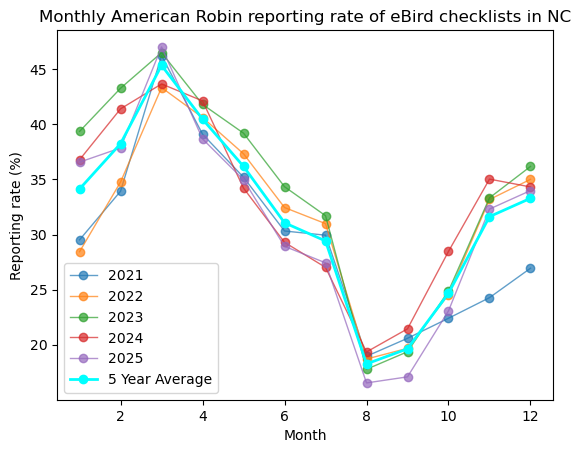

In [203]:
# plot a line for each year
for year, year_data in month_robins.groupby("year"):
    year_data = year_data.sort_values("month")
    plt.plot("month", "reporting_rate", data=year_data, marker="o", linewidth=1, alpha=0.7, label=str(year))

# plot the average over 5 years
average = month_robins.groupby("month")["reporting_rate"].mean()
average.plot(label="5 Year Average", marker="o", linewidth=2, alpha=1, color="cyan")

plt.xlabel("Month")
plt.ylabel("Reporting rate (%)")
plt.title("Monthly American Robin reporting rate of eBird checklists in NC")
plt.legend()
plt.show()